Adım 1: Hazırlık ve Dosya Yükleme

Adım 1: Dosya Yükleniyor...


Saving Mona_Lisa renkli normal.jpg to Mona_Lisa renkli normal.jpg


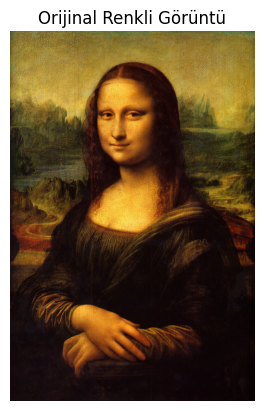

Görüntü başarıyla yüklendi.


In [ ]:
# Gerekli kütüphaneleri içe aktarın
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

print("Adım 1: Dosya Yükleniyor...")
# Dosyanızı Colab'a yükleyin. 'Mona_Lisa renkli normal.jpg' dosyasını seçin.
uploaded = files.upload()

# Yüklenen dosyanın adını alın
for filename in uploaded.keys():
    image_path = filename

# Görüntüyü renkli olarak oku
color_image = cv2.imread(image_path)

if color_image is None:
    print("Hata: Görüntü okunamadı. Dosya yolu veya adı yanlış olabilir.")
else:
    # OpenCV, görüntüyü BGR formatında okur. RGB formatına çevirelim.
    color_image_rgb = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)
    plt.imshow(color_image_rgb)
    plt.title('Orijinal Renkli Görüntü')
    plt.axis('off')
    plt.show()
    print("Görüntü başarıyla yüklendi.")

Adım 2: Renk Kanalı Histogram Analizi


Adım 2: Renk Kanalı Histogram Analizi


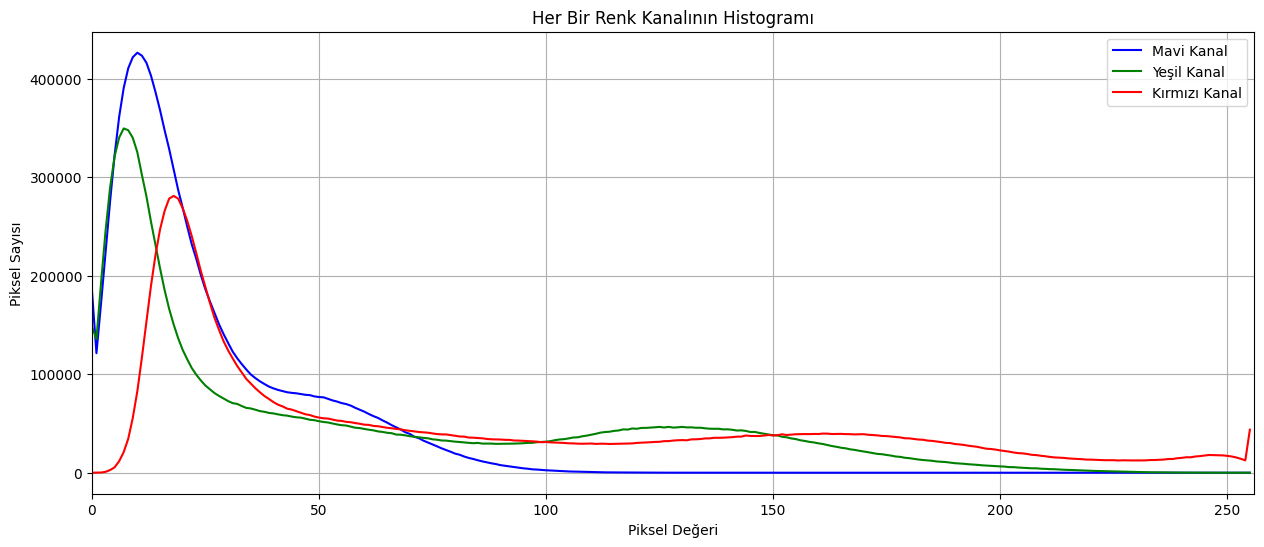

Histogramlar incelendiğinde, görüntünün genel renk tonlamasına uygun olarak her kanalın farklı bir dağılım sergilediği gözlemleniyor.


In [ ]:
print("\nAdım 2: Renk Kanalı Histogram Analizi")

# Renk kanallarını ayır
b, g, r = cv2.split(color_image)

# Her bir kanal için histogramları hesapla
hist_b = cv2.calcHist([b], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([g], [0], None, [256], [0, 256])
hist_r = cv2.calcHist([r], [0], None, [256], [0, 256])

# Histogramları çizdir
plt.figure(figsize=(15, 6))
plt.title('Her Bir Renk Kanalının Histogramı')
plt.xlabel("Piksel Değeri")
plt.ylabel("Piksel Sayısı")
plt.grid(True)
plt.plot(hist_b, color='blue', label='Mavi Kanal')
plt.plot(hist_g, color='green', label='Yeşil Kanal')
plt.plot(hist_r, color='red', label='Kırmızı Kanal')
plt.xlim([0, 256])
plt.legend()
plt.show()

print("Histogramlar incelendiğinde, görüntünün genel renk tonlamasına uygun olarak her kanalın farklı bir dağılım sergilediği gözlemleniyor.")

Adım 3 ve 4: Gri Tonlamaya Çevirme, Histogram Sıralama ve Eşikleme


Adım 3 ve 4: Gri Tonlamaya Çevirme ve Eşikleme


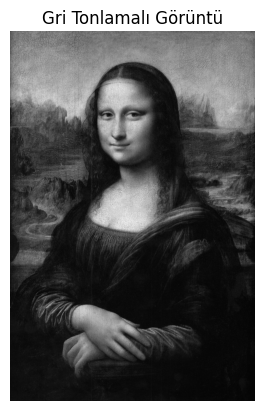


Histogram Piksel Değerleri (Piksel Sayısına Göre Sıralı):
Sıra 1: Piksel Değeri: 11, Sayısı: 331673
Sıra 2: Piksel Değeri: 10, Sayısı: 330113
Sıra 3: Piksel Değeri: 12, Sayısı: 327938
Sıra 4: Piksel Değeri: 13, Sayısı: 316749
Sıra 5: Piksel Değeri: 9, Sayısı: 315983
Sıra 6: Piksel Değeri: 14, Sayısı: 300120
Sıra 7: Piksel Değeri: 8, Sayısı: 292034
Sıra 8: Piksel Değeri: 15, Sayısı: 279601
Sıra 9: Piksel Değeri: 7, Sayısı: 260048
Sıra 10: Piksel Değeri: 16, Sayısı: 257122


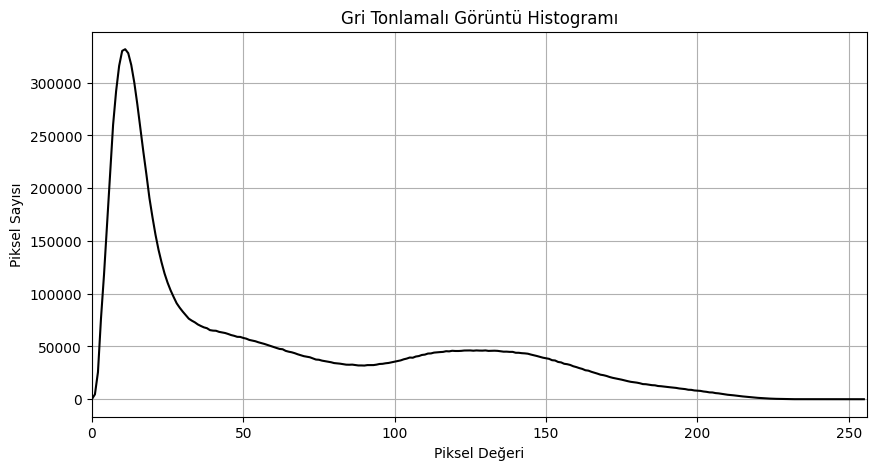

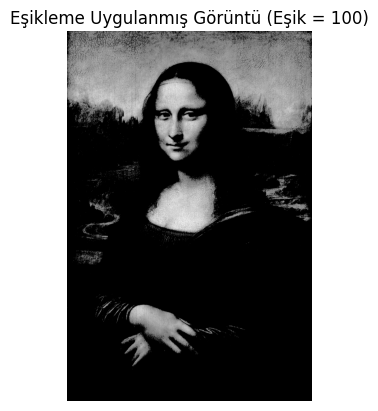

In [ ]:
print("\nAdım 3 ve 4: Gri Tonlamaya Çevirme ve Eşikleme")

# Renkli görüntüyü gri tonlamaya çevir
gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image, cmap='gray')
plt.title('Gri Tonlamalı Görüntü')
plt.axis('off')
plt.show()

# Gri tonlamalı görüntünün histogramını hesapla
hist_gray = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

# Piksel değerlerini ve piksel sayılarını birleştirip sıralama
pixels_and_counts = list(zip(range(256), hist_gray.flatten()))
pixels_and_counts.sort(key=lambda x: x[1], reverse=True) # En çok bulunan pikselden en aza doğru sırala

print("\nHistogram Piksel Değerleri (Piksel Sayısına Göre Sıralı):")
for i in range(10):
    print(f"Sıra {i+1}: Piksel Değeri: {pixels_and_counts[i][0]}, Sayısı: {pixels_and_counts[i][1]:.0f}")

# Histogram grafiği
plt.figure(figsize=(10, 5))
plt.title("Gri Tonlamalı Görüntü Histogramı")
plt.xlabel("Piksel Değeri")
plt.ylabel("Piksel Sayısı")
plt.grid(True)
plt.plot(hist_gray, color='black')
plt.xlim([0, 256])
plt.show()

# Manuel bir eşik değeri belirle. Örneğin, parlak pikselleri silmek için yüksek bir eşik.
# Mona Lisa'nın karanlık giysilerini ve arka planını ayırmak için deneme amaçlı 100 değeri kullanabiliriz.
# Resimdeki koyu bölgeler bu eşiğin altına düşecektir.
threshold_value = 100

# Eşikleme işlemi (thresholding). Belirlenen eşiğin altındaki tüm pikselleri 0 (siyah) yap.
# Bu, koyu bölgeleri tamamen silecektir.
# cv2.THRESH_BINARY_INV kullanırsak eşiğin üstü 0 olur.
# Biz eşiğin altını silmek istediğimiz için THRESH_BINARY kullanıyoruz ve beyazı 255'ten 0'a çekiyoruz.
# İyileştirme: cv2.threshold fonksiyonu, THRESH_BINARY ile eşiğin altındaki pikselleri 0 yapar.
# Bu durumda, 100'den küçük pikseller 0, büyük pikseller 255 olacaktır.
# Biz tam tersini yapalım: eşiğin altındaki pikselleri silmek için 0 yapalım.
_, thresholded_image = cv2.threshold(gray_image, threshold_value, 255, cv2.THRESH_BINARY)
# NOT: Eğer karanlık pikselleri silmek istiyorsanız yukarıdaki kod yerine aşağıdaki kullanılmalı:
# Sadece parlak bölgeleri bırakıp koyu bölgeleri (eşik altını) silmek
thresholded_image_silinen = np.where(gray_image < threshold_value, 0, gray_image)

plt.imshow(thresholded_image_silinen, cmap='gray')
plt.title(f'Eşikleme Uygulanmış Görüntü (Eşik = {threshold_value})')
plt.axis('off')
plt.show()

Adım 5: Sonuçların Karşılaştırılması


Adım 5: Sonuçların Karşılaştırması


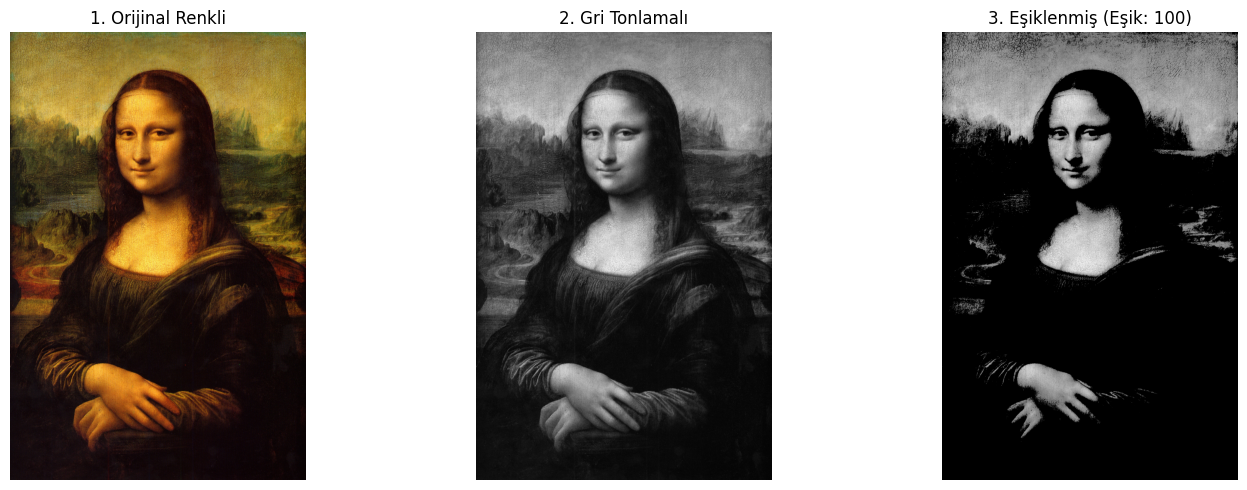


İşlem Özeti:
1. Renkli görüntünün her bir renk kanalının (RGB) histogramları ayrı ayrı analiz edildi.
2. Görüntü, eşikleme işlemi için gri tonlamaya çevrildi.
3. Gri tonlamalı histogram piksel sayısına göre sıralanarak, en yaygın renk tonları gözlemlendi.
4. Belirlenen 100 eşik değerinin altındaki tüm pikseller 'silinerek' (değeri 0 yapılarak) yeni bir görüntü oluşturuldu.
5. Sonuç görselleştirildiğinde, eşik değeri altında kalan koyu bölgelerin tamamen silindiği ve sadece parlak bölgelerin kaldığı görüldü.


In [ ]:
print("\nAdım 5: Sonuçların Karşılaştırması")

# Orijinal, gri tonlamalı ve işlenmiş görüntüleri yan yana göster
plt.figure(figsize=(15, 5))

# Orijinal Renkli Görüntü
plt.subplot(1, 3, 1)
plt.imshow(color_image_rgb)
plt.title('1. Orijinal Renkli')
plt.axis('off')

# Gri Tonlamalı Görüntü
plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap='gray')
plt.title('2. Gri Tonlamalı')
plt.axis('off')

# Eşiklenmiş Görüntü
plt.subplot(1, 3, 3)
plt.imshow(thresholded_image_silinen, cmap='gray')
plt.title(f'3. Eşiklenmiş (Eşik: {threshold_value})')
plt.axis('off')

plt.tight_layout()
plt.show()

print("\nİşlem Özeti:")
print("1. Renkli görüntünün her bir renk kanalının (RGB) histogramları ayrı ayrı analiz edildi.")
print("2. Görüntü, eşikleme işlemi için gri tonlamaya çevrildi.")
print("3. Gri tonlamalı histogram piksel sayısına göre sıralanarak, en yaygın renk tonları gözlemlendi.")
print(f"4. Belirlenen {threshold_value} eşik değerinin altındaki tüm pikseller 'silinerek' (değeri 0 yapılarak) yeni bir görüntü oluşturuldu.")
print("5. Sonuç görselleştirildiğinde, eşik değeri altında kalan koyu bölgelerin tamamen silindiği ve sadece parlak bölgelerin kaldığı görüldü.")